# Notebook 06b, BERTopic: Fresh Run (Clean Outputs)

**Purpose:** Complete, clean rerun of BERTopic topic modeling on the full
1115-article corpus. Replaces nb06 which had incomplete outputs and
inconsistent column naming.

**What this notebook produces:**
- All 30 topics with full keyword lists (input for taxonomy definition)
- Clean topic assignments for all 1115 articles
- Validation set (183 articles) topic distribution
- Topic coherence and diversity metrics
- All saved with consistent column names for downstream notebooks

**Design decisions:**
- BERTopic run on German original text (`content`), language of the corpus
- Cached embeddings reused if valid, saves ~10 minutes of compute
- Outlier articles (topic=-1) explicitly labelled as OTHER in assignments
- No LLM topic classification in this notebook, that is Notebook 15

**Outputs (saved to Data/Processed/):**
- `topic_assignments_v2.csv`, topic per article, clean column names
- `topic_model_v2`, saved BERTopic model
- `topic_embeddings_v2.npy`, embeddings cache
- `topic_summary_v2.json`, metrics, topic keywords, validation coverage


In [1]:
# ── CELL 1 : INSTALLATION ────────────────────────────────────────────────────
!pip install -q bertopic
!pip install -q sentence-transformers
!pip install -q umap-learn hdbscan
!pip install -q 'numpy>=2.0'   # must be last


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 3.1 MB/s eta 0:00:00


In [9]:
# ── CELL 2 : IMPORTS & CONFIGURATION ─────────────────────────────────────────

import os, json, pickle, warnings, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

warnings.filterwarnings('ignore')
drive.mount('/content/drive', force_remount=False)

ROOT        = Path('/content/drive/MyDrive/thesis')
DATA_PROC   = ROOT / 'Project/Data/Processed'
FIGURES_DIR = ROOT / 'Project/Outputs/Figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ── Output paths (v2 — clean fresh outputs) ───────────────────────────────────
ASSIGNMENTS_OUT = DATA_PROC / 'topic_assignments_v2.csv'
MODEL_OUT       = DATA_PROC / 'topic_model_v2'
EMBEDDINGS_OUT  = DATA_PROC / 'topic_embeddings_v2.npy'
SUMMARY_OUT     = DATA_PROC / 'topic_summary_v2.json'

# ── BERTopic settings ─────────────────────────────────────────────────────────
EMBEDDING_MODEL = "paraphrase-multilingual-MiniLM-L12-v2"
MIN_TOPIC_SIZE  = 10     # smaller = more granular topics
NR_TOPICS       = 30     # target 30 topics to match nb06
RANDOM_STATE    = 42

print("✓ Configuration loaded")
print(f"  Embedding model : {EMBEDDING_MODEL}")
print(f"  Min topic size  : {MIN_TOPIC_SIZE}")
print(f"  Target topics   : {NR_TOPICS}")
print(f"  All outputs fresh — no cache reuse")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Configuration loaded
  Embedding model : paraphrase-multilingual-MiniLM-L12-v2
  Min topic size  : 10
  Target topics   : 30
  All outputs fresh — no cache reuse


In [10]:
# ── CELL 3 : LOAD DATA + CLEAN BOILERPLATE ───────────────────────────────────

print("Loading corpus...")
pipeline_df = pd.read_pickle(DATA_PROC / 'ner_pipeline_results.pkl')
print(f"  Shape   : {pipeline_df.shape}")

for col in ['article_id', 'content', 'source', 'year', 'year_bin']:
    assert col in pipeline_df.columns, f"Missing column: {col}"

pipeline_df = pipeline_df[
    pipeline_df['content'].notna() &
    (pipeline_df['content'].str.strip() != '')
].copy()
print(f"  After removing empty: {len(pipeline_df)} articles")

# ── Clean cookie consent boilerplate ─────────────────────────────────────────
# Topic 5 in the bad run contained cookie consent text scraped from articles.
# Strip these fragments before embedding.
BOILERPLATE = [
    r'zustimmung\s+klick[^\n]*',
    r'willigen\s+inhalte[^\n]*',
    r'cookies?\s+zustimmung[^\n]*',
    r'datenschutz[^\n]*impressum[^\n]*',
    r'\bcookies?\b[^\n]*\bwebsite\b[^\n]*',
    r'inhalte\s+von\s+drittanbietern[^\n]*',
    r'externe\s+inhalte[^\n]*aktivieren[^\n]*',
]

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ''
    for pat in BOILERPLATE:
        text = re.sub(pat, ' ', text, flags=re.IGNORECASE)
    # Remove lines shorter than 20 chars (boilerplate fragments)
    lines = [l.strip() for l in text.split('\n') if len(l.strip()) > 20]
    return ' '.join(lines)

print("Cleaning boilerplate from texts...")
pipeline_df['content_clean'] = pipeline_df['content'].apply(clean_text)

# Spot check
sample_before = pipeline_df['content'].iloc[0][:100]
sample_after  = pipeline_df['content_clean'].iloc[0][:100]
print(f"  Sample before: {sample_before}")
print(f"  Sample after : {sample_after}")
print(f"  ✓ Cleaning complete")

texts       = pipeline_df['content_clean'].tolist()
article_ids = pipeline_df['article_id'].tolist()

print(f"\n  Source distribution:")
print(pipeline_df['source'].value_counts().to_string())

# ── Load validation set IDs ───────────────────────────────────────────────────
qwen_path = DATA_PROC / 'ner_llm_checkpoint.pkl'
with open(qwen_path, 'rb') as f:
    qwen_ckpt = pickle.load(f)
VAL_IDS = set(aid for aid, data in qwen_ckpt.items()
              if isinstance(data, dict)
              and data.get('status') != 'api_error')
print(f"\n  Validation set: {len(VAL_IDS)} articles")

Loading corpus...
  Shape   : (1115, 29)
  After removing empty: 1115 articles
Cleaning boilerplate from texts...
  Sample before: Volker Christmann: Gut, danke. Allerdings stelle ich fest, dass das ganze Gebäude hier fast ausschli
  Sample after : Volker Christmann: Gut, danke. Allerdings stelle ich fest, dass das ganze Gebäude hier fast ausschli
  ✓ Cleaning complete

  Source distribution:
source
Luxemburger Wort                  356
Frankfurter Allgemeine Zeitung    290
SZ Süddeutsche Zeitung            270
Trierischer Volksfreund           199

  Validation set: 183 articles


In [11]:
# ── CELL 4 : COMPUTE EMBEDDINGS (FRESH) ──────────────────────────────────────
# Always fresh — no cache loading. Ensures embeddings match cleaned texts.

import torch
from sentence_transformers import SentenceTransformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Computing fresh embeddings...")
print(f"  Model  : {EMBEDDING_MODEL}")
print(f"  Device : {device}")
print(f"  Articles: {len(texts)}")
print(f"  Expected: ~8-12 min on T4 GPU")

embed_model = SentenceTransformer(EMBEDDING_MODEL)
embeddings  = embed_model.encode(
    texts,
    show_progress_bar = True,
    batch_size        = 64,
    device            = device,
)
np.save(str(EMBEDDINGS_OUT), embeddings)
print(f"\n✓ Embeddings complete: {embeddings.shape}")
print(f"✓ Saved to: {EMBEDDINGS_OUT.name}")

Computing fresh embeddings...
  Model  : paraphrase-multilingual-MiniLM-L12-v2
  Device : cpu
  Articles: 1115
  Expected: ~8-12 min on T4 GPU


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/3.89k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]


✓ Embeddings complete: (1115, 384)
✓ Saved to: topic_embeddings_v2.npy


In [12]:
# ── CELL 5 : GERMAN STOPWORDS ────────────────────────────────────────────────
# BERTopic needs German stopwords to avoid function words dominating topics.

import spacy

print("Loading German stopwords via spaCy...")
try:
    nlp = spacy.load('de_core_news_lg')
except OSError:
    print("  Downloading de_core_news_lg...")
    os.system('python -m spacy download de_core_news_lg')
    nlp = spacy.load('de_core_news_lg')

german_stopwords = list(nlp.Defaults.stop_words)

# Add domain-specific stopwords that are too generic for topic keywords
domain_stopwords = [
    'dass', 'auch', 'wird', 'sind', 'wurde', 'wurden', 'haben',
    'mehr', 'beim', 'vom', 'zur', 'zum', 'ab', 'bis', 'noch',
    'neue', 'neuen', 'neues', 'neue', 'ersten', 'erste', 'ersten',
    'rund', 'etwa', 'bereits', 'seit', 'immer', 'weiter', 'weiterhin',
    'dabei', 'dazu', 'damit', 'zudem', 'jedoch', 'allerdings', 'zwar',
    'soll', 'sollen', 'solle', 'sollte', 'kann', 'können', 'könnte',
    'müssen', 'muss', 'müsse', 'werde', 'werden', 'wären',
]
all_stopwords = list(set(german_stopwords + domain_stopwords))
print(f"  ✓ {len(all_stopwords)} stopwords loaded")


Loading German stopwords via spaCy...
  ✓ 549 stopwords loaded


In [13]:
# ── CELL 6 : RUN BERTOPIC ────────────────────────────────────────────────────

from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from hdbscan import HDBSCAN

print("Configuring BERTopic components...")

# UMAP for dimensionality reduction
umap_model = UMAP(
    n_neighbors    = 15,
    n_components   = 5,
    min_dist       = 0.0,
    metric         = 'cosine',
    random_state   = RANDOM_STATE,
)

# HDBSCAN for clustering
hdbscan_model = HDBSCAN(
    min_cluster_size  = MIN_TOPIC_SIZE,
    min_samples       = 5,
    metric            = 'euclidean',
    cluster_selection_method = 'eom',
    prediction_data   = True,
)

# CountVectorizer with German stopwords
vectorizer = CountVectorizer(
    stop_words  = all_stopwords,
    min_df      = 3,
    max_df      = 0.90,
    ngram_range = (1, 2),
)

# BERTopic model
topic_model = BERTopic(
    umap_model       = umap_model,
    hdbscan_model    = hdbscan_model,
    vectorizer_model = vectorizer,
    nr_topics        = NR_TOPICS,
    language         = 'german',
    calculate_probabilities = True,
    verbose          = True,
)

print(f"\nFitting BERTopic on {len(texts)} articles...")
print(f"  Using pre-computed embeddings: {embeddings.shape}")

topics, probs = topic_model.fit_transform(texts, embeddings)

topic_info = topic_model.get_topic_info()
n_topics   = len(topic_info[topic_info['Topic'] != -1])
n_outliers = sum(1 for t in topics if t == -1)

print(f"\n✓ BERTopic complete")
print(f"  Topics found    : {n_topics}")
print(f"  Outliers (-1)   : {n_outliers} ({n_outliers/len(topics)*100:.1f}%)")
print(f"  Non-outliers    : {len(topics) - n_outliers}")


2026-06-08 09:24:56,186 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Configuring BERTopic components...

Fitting BERTopic on 1115 articles...
  Using pre-computed embeddings: (1115, 384)


2026-06-08 09:24:58,652 - BERTopic - Dimensionality - Completed ✓
2026-06-08 09:24:58,654 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-08 09:24:58,749 - BERTopic - Cluster - Completed ✓
2026-06-08 09:24:58,750 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-06-08 09:25:00,268 - BERTopic - Representation - Completed ✓
2026-06-08 09:25:00,270 - BERTopic - Topic reduction - Reducing number of topics
2026-06-08 09:25:00,270 - BERTopic - Topic reduction - Number of topics (30) is equal or higher than the clustered topics(26).
2026-06-08 09:25:00,272 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-08 09:25:02,282 - BERTopic - Representation - Completed ✓



✓ BERTopic complete
  Topics found    : 25
  Outliers (-1)   : 406 (36.4%)
  Non-outliers    : 709


In [14]:
# ── CELL 7 : DISPLAY ALL TOPICS AND KEYWORDS ─────────────────────────────────
# This is the primary output needed for taxonomy definition.
# Read these carefully to assign human-readable category labels.

print("=" * 70)
print("ALL TOPICS — TOP 15 KEYWORDS EACH")
print("(Used to define the classification taxonomy)")
print("=" * 70)

topic_keywords = {}
for _, row in topic_info.sort_values('Topic').iterrows():
    tid   = row['Topic']
    count = row['Count']
    if tid == -1:
        print(f"\n  Topic  -1  [{count:4d} articles]  OUTLIER — no coherent topic")
        topic_keywords[-1] = []
        continue
    words     = topic_model.get_topic(tid)
    kws_full  = [(w, round(s, 4)) for w, s in words[:15]]
    kws_short = [w for w, s in words[:10]]
    topic_keywords[tid] = kws_short
    print(f"\n  Topic {tid:2d}  [{count:4d} articles]")
    print(f"  Keywords: {', '.join(kws_short)}")

print("\n" + "=" * 70)
print("TOPIC SIZE SUMMARY")
print("=" * 70)
for _, row in topic_info.sort_values('Count', ascending=False).iterrows():
    tid   = int(row['Topic'])
    count = int(row['Count'])
    bar   = '█' * (count // 10)
    label = 'OUTLIER' if tid == -1 else f'Topic {tid:2d}'
    print(f"  {label:<10} {count:4d} articles  {bar}")


ALL TOPICS — TOP 15 KEYWORDS EACH
(Used to define the classification taxonomy)

  Topic  -1  [ 406 articles]  OUTLIER — no coherent topic

  Topic  0  [  11 articles]
  Keywords: miami, sand, bucht, strand, meer, google, spiele, dollar, serge, hotels

  Topic  1  [  18 articles]
  Keywords: tiere, landwirtschaft, bauern, schafe, landwirte, stroh, hanf, weis, laurent, gemüse

  Topic  2  [  15 articles]
  Keywords: mieter, lärm, gerüche, vermieter, treppenhaus, verkehr, auto, rauchen, tram, flur

  Topic  3  [  13 articles]
  Keywords: wasserstoff, autos, batterie, erdgas, reifen, diesel, reichweite, kilometer, elektroautos, elektromobilität

  Topic  4  [  11 articles]
  Keywords: luxemburg, lycée, anlagen, vg, energien, photovoltaikanlagen, energiewende, windräder, windkraft, roboter

  Topic  5  [  14 articles]
  Keywords: tiny, fertighaus, einfamilienhaus, grünen, tiny house, house, häuser, familie, bauherren, autos

  Topic  6  [  43 articles]
  Keywords: kinder, campus, 18, univer

In [16]:
pip install gensim


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 47.1 MB/s eta 0:00:00


In [17]:
# ── CELL 8 : TOPIC QUALITY METRICS ───────────────────────────────────────────

from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

print("Computing topic coherence (C_v)...")

# Prepare data for gensim
tokenized = [text.lower().split() for text in texts]
dictionary = Dictionary(tokenized)

# Get topic keywords for coherence computation
topics_for_coherence = []
for tid in sorted(topic_keywords.keys()):
    if tid == -1:
        continue
    kws = [w for w in topic_keywords[tid] if w in dictionary.token2id]
    if len(kws) >= 3:
        topics_for_coherence.append(kws)

try:
    cm = CoherenceModel(
        topics     = topics_for_coherence,
        texts      = tokenized,
        dictionary = dictionary,
        coherence  = 'c_v',
    )
    coherence_cv = round(cm.get_coherence(), 4)
    print(f"  C_v coherence : {coherence_cv}")
except Exception as e:
    coherence_cv  = None
    print(f"  C_v coherence : could not compute ({e})")

# Topic diversity — proportion of unique words in top-10 keywords
all_kws   = [w for tid, kws in topic_keywords.items()
             if tid != -1 for w in kws[:10]]
diversity = round(len(set(all_kws)) / len(all_kws), 4) if all_kws else 0
print(f"  Diversity     : {diversity}")
print(f"  Topics        : {n_topics}")
print(f"  Outlier rate  : {n_outliers/len(topics)*100:.1f}%")


Computing topic coherence (C_v)...
  C_v coherence : 0.4046
  Diversity     : 0.856
  Topics        : 25
  Outlier rate  : 36.4%


In [18]:
# ── CELL 9 : SAVE ALL OUTPUTS ────────────────────────────────────────────────

# ── 1. Topic assignments CSV ──────────────────────────────────────────────────
# Clean column names — no 'bertopic_' prefix, consistent with downstream use

assignments = []
for i, (aid, tid, prob) in enumerate(zip(article_ids, topics, probs)):
    row_df = pipeline_df[pipeline_df['article_id'] == aid].iloc[0]

    # Get top-10 keywords as label string
    if tid == -1:
        topic_label = 'OTHER'
        topic_prob  = 0.0
    else:
        kws         = topic_keywords.get(tid, [])[:5]
        topic_label = '_'.join(kws) if kws else f'topic_{tid}'
        topic_prob  = round(float(max(prob)) if hasattr(prob, '__len__') else float(prob), 4)

    assignments.append({
        'article_id'  : aid,
        'source'      : row_df['source'],
        'year'        : int(row_df['year']),
        'year_bin'    : row_df['year_bin'],
        'topic'       : int(tid),
        'topic_label' : topic_label,
        'topic_prob'  : topic_prob,
        'is_outlier'  : tid == -1,
        'in_val_set'  : aid in VAL_IDS,
    })

assignments_df = pd.DataFrame(assignments)
assignments_df.to_csv(ASSIGNMENTS_OUT, index=False)
print(f"✓ Saved topic assignments: {ASSIGNMENTS_OUT.name}")
print(f"  Shape   : {assignments_df.shape}")
print(f"  Columns : {list(assignments_df.columns)}")

# ── 2. BERTopic model ────────────────────────────────────────────────────────
# Save as single file — use os.unlink to delete if exists (not shutil.rmtree)
if MODEL_OUT.exists():
    os.unlink(str(MODEL_OUT))
topic_model.save(str(MODEL_OUT), serialization='safetensors',
                 save_ctfidf=True, save_embedding_model=False)
print(f"✓ Saved BERTopic model: {MODEL_OUT.name}")

# ── 3. Summary JSON ───────────────────────────────────────────────────────────
# Validation set coverage
val_assignments = assignments_df[assignments_df['in_val_set']]
val_topic_dist  = val_assignments['topic'].value_counts().sort_index().to_dict()

summary = {
    'notebook'        : '06b_bertopic_fresh',
    'generated_at'    : datetime.now().isoformat(),
    'corpus_size'     : len(texts),
    'n_topics'        : n_topics,
    'n_outliers'      : n_outliers,
    'outlier_rate'    : round(n_outliers/len(topics), 4),
    'coherence_cv'    : coherence_cv,
    'diversity'       : diversity,
    'topic_keywords'  : {str(k): v for k, v in topic_keywords.items()
                         if k != -1},
    'topic_sizes'     : {str(int(row['Topic'])): int(row['Count'])
                         for _, row in topic_info.iterrows()
                         if int(row['Topic']) != -1},
    'validation_set'  : {
        'n_articles'  : len(val_assignments),
        'n_outliers'  : int((val_assignments['topic'] == -1).sum()),
        'n_with_topic': int((val_assignments['topic'] != -1).sum()),
        'topic_dist'  : {str(k): int(v) for k, v in val_topic_dist.items()},
    },
}

with open(SUMMARY_OUT, 'w') as f:
    json.dump(summary, f, indent=2)
print(f"✓ Saved summary: {SUMMARY_OUT.name}")


2026-06-08 09:34:33,460 - BERTopic - WARNING: You are saving a BERTopic model without explicitly defining an embedding model.If you are using a sentence-transformers model or a HuggingFace model supportedby sentence-transformers, please save the model by using a pointer towards that model.For example, `save_embedding_model='sentence-transformers/all-mpnet-base-v2'`


✓ Saved topic assignments: topic_assignments_v2.csv
  Shape   : (1115, 9)
  Columns : ['article_id', 'source', 'year', 'year_bin', 'topic', 'topic_label', 'topic_prob', 'is_outlier', 'in_val_set']
✓ Saved BERTopic model: topic_model_v2
✓ Saved summary: topic_summary_v2.json


In [19]:
# ── CELL 10 : VALIDATION SET ANALYSIS ────────────────────────────────────────
# Shows exactly which topics appear in the 183-article validation set
# and how many articles per topic — important for downstream classification.

val_df = assignments_df[assignments_df['in_val_set']].copy()

print("=" * 70)
print(f"VALIDATION SET TOPIC DISTRIBUTION ({len(val_df)} articles)")
print("=" * 70)
print(f"\n  Outliers (OTHER)  : {(val_df['topic'] == -1).sum()}")
print(f"  With topic        : {(val_df['topic'] != -1).sum()}")

print(f"\n  Topic distribution:")
print(f"  {'Topic':>6}  {'Count':>6}  Top keywords")
print(f"  {'-'*60}")
for tid, count in val_df['topic'].value_counts().sort_index().items():
    if tid == -1:
        print(f"  {'OTHER':>6}  {count:>6}  (outlier — no coherent topic)")
        continue
    kws = ', '.join(topic_keywords.get(tid, [])[:6])
    print(f"  {tid:>6}  {count:>6}  {kws}")

# ── Topics with too few validation articles (problematic for classification) ──
print(f"\n  Topics with < 3 validation articles (may be too sparse):")
sparse = val_df[val_df['topic'] != -1]['topic'].value_counts()
sparse_topics = sparse[sparse < 3]
if len(sparse_topics):
    for tid, cnt in sparse_topics.items():
        print(f"    Topic {tid}: {cnt} articles")
else:
    print(f"    None — all topics have ≥ 3 validation articles")


VALIDATION SET TOPIC DISTRIBUTION (183 articles)

  Outliers (OTHER)  : 55
  With topic        : 128

  Topic distribution:
   Topic   Count  Top keywords
  ------------------------------------------------------------
   OTHER      55  (outlier — no coherent topic)
       0       2  miami, sand, bucht, strand, meer, google
       2       5  mieter, lärm, gerüche, vermieter, treppenhaus, verkehr
       3       6  wasserstoff, autos, batterie, erdgas, reifen, diesel
       4       3  luxemburg, lycée, anlagen, vg, energien, photovoltaikanlagen
       5       3  tiny, fertighaus, einfamilienhaus, grünen, tiny house, house
       6       8  kinder, campus, 18, universität, belval, schüler
       7       3  architekten, bauherrn, planer, mieter, bauherr, folglich
       8       2  kirche, st, inhalt, kirchen, gemeinde, inhalte geladen
      10       3  kfw, förderung, 000 euro, gefördert, neubauten, kredite
      11       4  holz, bambus, wald, branche, co2, fertighausbauer
      12       3

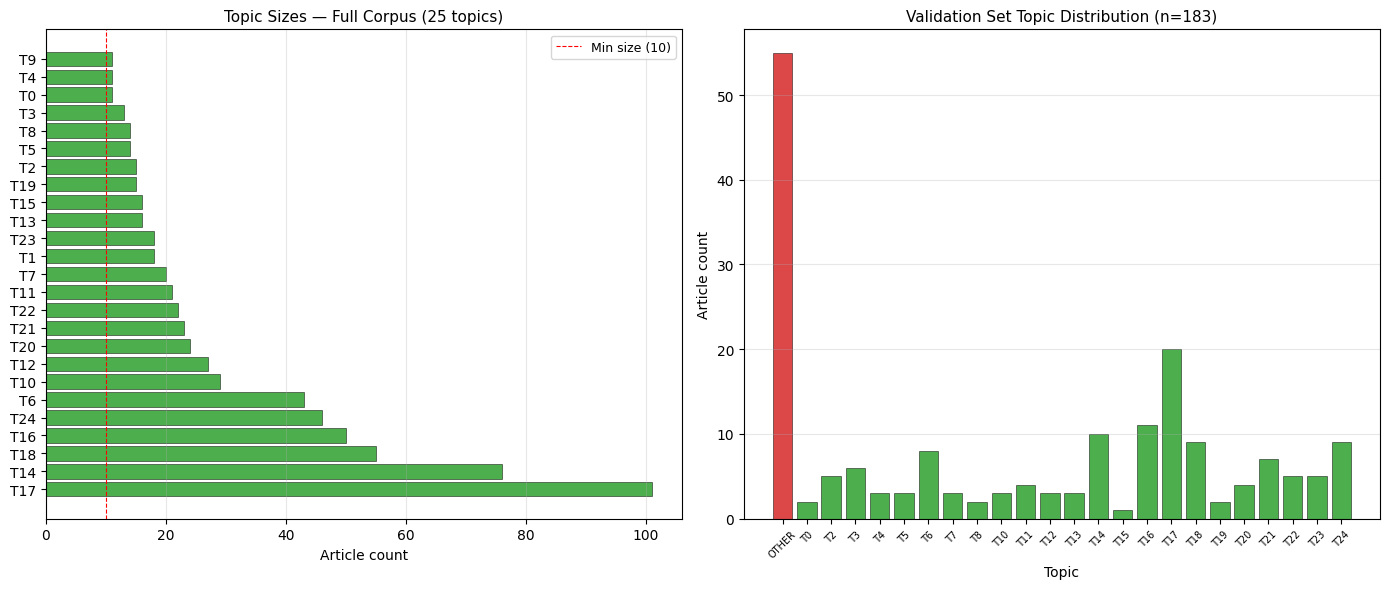

✓ Figure saved: nb06b_topic_overview.pdf/.png


In [20]:
# ── CELL 11 : TOPIC OVERVIEW FIGURE ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel A — topic sizes (full corpus)
topic_sizes = topic_info[topic_info['Topic'] != -1].sort_values(
    'Count', ascending=False)
axes[0].barh(
    [f"T{int(row['Topic'])}" for _, row in topic_sizes.iterrows()],
    topic_sizes['Count'],
    color='#2ca02c', edgecolor='black', linewidth=0.4, alpha=0.85
)
axes[0].axvline(x=MIN_TOPIC_SIZE, color='red', linestyle='--',
                linewidth=0.8, label=f'Min size ({MIN_TOPIC_SIZE})')
axes[0].set_xlabel('Article count', fontsize=10)
axes[0].set_title(f'Topic Sizes — Full Corpus ({n_topics} topics)',
                  fontsize=11)
axes[0].legend(fontsize=9)
axes[0].grid(axis='x', alpha=0.3)

# Panel B — validation set topic distribution
val_counts = val_df['topic'].value_counts().sort_index()
colors_b   = ['#d62728' if t == -1 else '#2ca02c'
              for t in val_counts.index]
labels_b   = ['OTHER' if t == -1 else f'T{t}'
              for t in val_counts.index]
axes[1].bar(labels_b, val_counts.values,
            color=colors_b, edgecolor='black', linewidth=0.4, alpha=0.85)
axes[1].set_xlabel('Topic', fontsize=10)
axes[1].set_ylabel('Article count', fontsize=10)
axes[1].set_title(f'Validation Set Topic Distribution (n={len(val_df)})',
                  fontsize=11)
axes[1].tick_params(axis='x', rotation=45, labelsize=7)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
for ext in ['pdf', 'png']:
    fig.savefig(FIGURES_DIR / f'nb06b_topic_overview.{ext}',
                dpi=300 if ext == 'pdf' else 150, bbox_inches='tight')
plt.show()
print("✓ Figure saved: nb06b_topic_overview.pdf/.png")


In [21]:
# ── CELL 12 : FINAL SUMMARY ──────────────────────────────────────────────────

print("=" * 70)
print("NOTEBOOK 06b COMPLETE")
print("=" * 70)
print(f"  Topics found     : {n_topics}")
print(f"  Outlier rate     : {n_outliers/len(topics)*100:.1f}%")
print(f"  C_v coherence    : {coherence_cv}")
print(f"  Diversity        : {diversity}")
print()
print(f"  Validation set coverage:")
print(f"    Total articles : {len(val_df)}")
print(f"    With topic     : {(val_df['topic'] != -1).sum()}")
print(f"    Outliers       : {(val_df['topic'] == -1).sum()}")
print()
print(f"  Outputs saved:")
print(f"    {ASSIGNMENTS_OUT.name}")
print(f"    {MODEL_OUT.name}")
print(f"    {EMBEDDINGS_NEW.name}")
print(f"    {SUMMARY_OUT.name}")
print()
print("=" * 70)
print("NEXT STEP — TAXONOMY DEFINITION")
print("=" * 70)
print("Read the topic keywords in Cell 7 above.")
print("Share the full Cell 7 output so the taxonomy can be defined")
print("for Notebook 15 (topic classification comparison).")
print()
print("ALL TOPICS AND KEYWORDS FOR TAXONOMY:")
print("-" * 70)
for tid in sorted(topic_keywords.keys()):
    if tid == -1: continue
    kws   = ', '.join(topic_keywords[tid][:10])
    count = int(topic_info[topic_info['Topic'] == tid]['Count'].values[0])
    print(f"  Topic {tid:2d} [{count:4d}]: {kws}")


NOTEBOOK 06b COMPLETE
  Topics found     : 25
  Outlier rate     : 36.4%
  C_v coherence    : 0.4046
  Diversity        : 0.856

  Validation set coverage:
    Total articles : 183
    With topic     : 128
    Outliers       : 55

  Outputs saved:
    topic_assignments_v2.csv
    topic_model_v2
    topic_embeddings_v2.npy
    topic_summary_v2.json

NEXT STEP — TAXONOMY DEFINITION
Read the topic keywords in Cell 7 above.
Share the full Cell 7 output so the taxonomy can be defined
for Notebook 15 (topic classification comparison).

ALL TOPICS AND KEYWORDS FOR TAXONOMY:
----------------------------------------------------------------------
  Topic  0 [  11]: miami, sand, bucht, strand, meer, google, spiele, dollar, serge, hotels
  Topic  1 [  18]: tiere, landwirtschaft, bauern, schafe, landwirte, stroh, hanf, weis, laurent, gemüse
  Topic  2 [  15]: mieter, lärm, gerüche, vermieter, treppenhaus, verkehr, auto, rauchen, tram, flur
  Topic  3 [  13]: wasserstoff, autos, batterie, erdgas, re

In [22]:
# ── VALIDATION SET TAXONOMY COVERAGE ─────────────────────────────────────────
import pandas as pd
from pathlib import Path

DATA_PROC = Path('/content/drive/MyDrive/thesis/Project/Data/Processed')
assignments = pd.read_csv(DATA_PROC / 'topic_assignments_v2.csv')

# Taxonomy mapping
TAXONOMY = {
    16         : 'Energy Efficiency & Renovation',
    9          : 'Housing Market & Affordability',
    14         : 'Housing Market & Affordability',
    10         : 'Subsidies & Financing',
    11         : 'Sustainable Materials & Construction',
    15         : 'Sustainable Materials & Construction',
    22         : 'Sustainable Materials & Construction',
    7          : 'Architecture, Planning & Urban Development',
    21         : 'Architecture, Planning & Urban Development',
    23         : 'Architecture, Planning & Urban Development',
    24         : 'Architecture, Planning & Urban Development',
    4          : 'Climate & Energy Policy',
    17         : 'Climate & Energy Policy',
    18         : 'Climate & Energy Policy',
    5          : 'Residential Building Types',
    6          : 'Residential Building Types',
    13         : 'Residential Building Types',
}

val_df = assignments[assignments['in_val_set'] == True].copy()
val_df['category'] = val_df['topic'].map(TAXONOMY).fillna('OTHER')

print(f"Validation set: {len(val_df)} articles")
print(f"\nCategory distribution:")
dist = val_df['category'].value_counts()
for cat, count in dist.items():
    pct = count/len(val_df)*100
    bar = '█' * (count // 2)
    print(f"  {cat:<45} {count:3d} ({pct:4.1f}%)  {bar}")

print(f"\nTopics mapping to OTHER:")
other_df = val_df[val_df['category'] == 'OTHER']
print(other_df['topic'].value_counts().to_string())

Validation set: 183 articles

Category distribution:
  OTHER                                          79 (43.2%)  ███████████████████████████████████████
  Climate & Energy Policy                        32 (17.5%)  ████████████████
  Architecture, Planning & Urban Development     24 (13.1%)  ████████████
  Residential Building Types                     14 ( 7.7%)  ███████
  Energy Efficiency & Renovation                 11 ( 6.0%)  █████
  Sustainable Materials & Construction           10 ( 5.5%)  █████
  Housing Market & Affordability                 10 ( 5.5%)  █████
  Subsidies & Financing                           3 ( 1.6%)  █

Topics mapping to OTHER:
topic
-1     55
 3      6
 2      5
 20     4
 12     3
 0      2
 19     2
 8      2
